In [ ]:
from pyaedt import maxwell  # Or change to Maxwell etc. according to the project tool
import csv
import os
import tempfile
import time
from operator import attrgetter
import ansys.aedt.core
import glob
from pathlib import Path

# Temporarily commented out - will be replaced with Maxwell 2D instance later
# project_name = os.path.join(temp_folder.name, "PM_Motor.aedt")
# m3d = ansys.aedt.core.Maxwell3d(
#     project=project_name,
#     version=AEDT_VERSION,
#     new_desktop=True,
#     non_graphical=NG_MODE,
# )

# Example of object information output (to be used with actual Maxwell instance later)
# all_objects = m2d.modeler.object_names
# for obj_name in all_objects:
#     obj = m2d.modeler[obj_name]
#     print(f"Name: {obj.name}, Material: {obj.material_name}, Volume: {obj.volume}")


def find_aedt_files(search_path="."):
    """
    Function to find files with .aedt extension

    Args:
        search_path (str): Path to search (default: current directory)

    Returns:
        list: List of .aedt file paths
    """
    aedt_files = []

    # Method 1: Using glob
    pattern = os.path.join(search_path, "**", "*.aedt")
    aedt_files_glob = glob.glob(pattern, recursive=True)

    # Method 2: Using pathlib (more modern approach)
    search_dir = Path(search_path)
    aedt_files_pathlib = list(search_dir.rglob("*.aedt"))

    # Convert to absolute paths
    aedt_files_glob = [os.path.abspath(f) for f in aedt_files_glob]
    aedt_files_pathlib = [str(f.absolute()) for f in aedt_files_pathlib]

    print(f"Search path: {os.path.abspath(search_path)}")
    print(f"Number of .aedt files found: {len(aedt_files_glob)}")
    print("\n=== Found .aedt files ===")

    if aedt_files_glob:
        for i, file_path in enumerate(aedt_files_glob, 1):
            print(f"{i}. {file_path}")
    else:
        print("No .aedt files found in this path.")

    return aedt_files_glob


# Find .aedt files in current directory
current_dir_files = find_aedt_files(".")

print("\n" + "=" * 50)

# Find in specific path (modify path if needed)
# workspace_path = r"d:\KangDH\Emlab_emach"
# workspace_files = find_aedt_files(workspace_path)


검색 경로: c:\Users\user\Downloads
발견된 .aedt 파일 수: 0

=== 발견된 .aedt 파일들 ===
해당 경로에서 .aedt 파일을 찾을 수 없습니다.



In [1]:
# # PM synchronous motor transient analysis
#
# This example shows how to use PyAEDT to create a Maxwell 2D transient analysis for
# an interior permanent magnet (PM) electric motor.
#
# Keywords: **Maxwell 2D**, **transient**, **motor**.

# ## Perform imports and define constants
#
# Perform required imports.

# +
import csv
import os
import tempfile
import time
from operator import attrgetter

import ansys.aedt.core

# Define constants.

AEDT_VERSION = "2025.1"
NUM_CORES = 4
NG_MODE = False  # Open AEDT UI when it is launched.

# ## Create temporary directory and download files
#
# Create a temporary directory where downloaded data or
# dumped data can be stored.
# If you'd like to retrieve the project data for subsequent use,
# the temporary folder name is given by ``temp_folder.name``.

temp_folder = tempfile.TemporaryDirectory(suffix=".ansys")


In [2]:

# ## Initialize dictionaries
#
# Dictionaries contain all the definitions for the design variables and output variables.

# ## Initialize definitions for th stator, rotor, and shaft
#
# Initialize geometry parameter definitions for the stator, rotor, and shaft.
# The naming refers to RMxprt primitives.

geom_params = {
    "DiaGap": "132mm",
    "DiaStatorYoke": "198mm",
    "DiaStatorInner": "132mm",
    "DiaRotorLam": "130mm",
    "DiaShaft": "44.45mm",
    "DiaOuter": "198mm",
    "Airgap": "1mm",
    "SlotNumber": "48",
    "SlotType": "3",
}

# ## Initialize definitions for stator windings
#
# Initialize geometry parameter definitions for the stator windings. The naming
# refers to RMxprt primitives.

wind_params = {
    "Layers": "1",
    "ParallelPaths": "2",
    "R_Phase": "7.5mOhm",
    "WdgExt_F": "5mm",
    "SpanExt": "30mm",
    "SegAngle": "0.25",
    "CoilPitch": "5",  # coil pitch in slots
    "Coil_SetBack": "3.605732823mm",
    "SlotWidth": "2.814mm",  # RMxprt Bs0
    "Coil_Edge_Short": "3.769235435mm",
    "Coil_Edge_Long": "15.37828521mm",
}

# ## Initialize definitions for model setup
#
# Initialize geometry parameter definitions for the model setup.

mod_params = {
    "NumPoles": "8",
    "Model_Length": "80mm",
    "SymmetryFactor": "8",
    "Magnetic_Axial_Length": "150mm",
    "Stator_Lam_Length": "0mm",
    "StatorSkewAngle": "0deg",
    "NumTorquePointsPerCycle": "30",
    "mapping_angle": "0.125*4deg",
    "num_m": "16",
    "Section_Angle": "360deg/SymmetryFactor",
}

# ## Initialize definitions for operational machine
#
# Initialize geometry parameter definitions for the operational machine. This
# identifies the operating point for the transient setup.

oper_params = {
    "InitialPositionMD": "180deg/4",
    "IPeak": "480A",
    "MachineRPM": "3000rpm",
    "ElectricFrequency": "MachineRPM/60rpm*NumPoles/2*1Hz",
    "ElectricPeriod": "1/ElectricFrequency",
    "BandTicksinModel": "360deg/NumPoles/mapping_angle",
    "TimeStep": "ElectricPeriod/(2*BandTicksinModel)",
    "StopTime": "ElectricPeriod",
    "Theta_i": "135deg",
}

# ## Launch AEDT and Maxwell 2D
#
# Launch AEDT and Maxwell 2D after first setting up the project and design names,
# the solver, and the version. The following code also creates an instance of the
# ``Maxwell2d`` class named ``m2d``.


In [3]:

project_name = os.path.join(temp_folder.name, "PM_Motor.aedt")
m2d = ansys.aedt.core.Maxwell2d(
    project=project_name,
    version=AEDT_VERSION,
    design="Sinusoidal",
    solution_type="TransientXY",
    new_desktop=False,
    non_graphical=NG_MODE,
)

# ## Define modeler units

m2d.modeler.model_units = "mm"


PyAEDT INFO: Python version 3.8.10 (tags/v3.8.10:3d8993a, May  3 2021, 11:48:03) [MSC v.1928 64 bit (AMD64)]
PyAEDT INFO: PyAEDT version 0.13.0.
PyAEDT INFO: Initializing new Desktop session.
PyAEDT INFO: Log on console is enabled.
PyAEDT INFO: Log on file C:\Users\user\AppData\Local\Temp\pyaedt_user_ecd2f207-fa57-43d0-853c-5e9c7f0470c6.log is enabled.
PyAEDT INFO: Log on AEDT is enabled.
PyAEDT INFO: Debug logger is disabled. PyAEDT methods will not be logged.
PyAEDT INFO: Launching PyAEDT with gRPC plugin.
PyAEDT INFO: New AEDT session is starting on gRPC port 63412
PyAEDT INFO: AEDT installation Path C:\Program Files\ANSYS Inc\v251\AnsysEM
PyAEDT INFO: Ansoft.ElectronicsDesktop.2025.1 version started with process ID 2092.
PyAEDT INFO: Project PM_Motor has been created.
PyAEDT INFO: Added design 'Sinusoidal' of type Maxwell 2D.
PyAEDT INFO: Aedt Objects correctly read
PyAEDT INFO: Modeler2D class has been initialized!
PyAEDT INFO: Modeler class has been initialized! Elapsed time: 0m 

## Define variables from dictionaries


In [4]:

# ## Define variables from dictionaries
#
# Define design variables from the created dictionaries.

for k, v in geom_params.items():
    m2d[k] = v
for k, v in wind_params.items():
    m2d[k] = v
for k, v in mod_params.items():
    m2d[k] = v
for k, v in oper_params.items():
    m2d[k] = v   


In [6]:

# ## Define path for non-linear material properties
#
# Define the path for non-linear material properties.
# Materials are stored in text files.

# 임시로 예시 파일 경로 생성 (실제 사용 시 적절한 material 파일 경로로 변경)
import os
filename_lam = os.path.join(temp_folder.name, "30DH_20C_smooth.txt")
filename_PM = os.path.join(temp_folder.name, "Arnold_Magnetics_N30UH_80C.txt")

# 예시 material 데이터 파일 생성
with open(filename_lam, 'w') as f:
    f.write("H(A/m)\tB(T)\n")
    f.write("0\t0\n")
    f.write("100\t0.5\n")
    f.write("500\t1.0\n")
    f.write("1000\t1.3\n")
    f.write("2000\t1.5\n")
    f.write("5000\t1.7\n")
    f.write("10000\t1.8\n")

with open(filename_PM, 'w') as f:
    f.write("H(A/m)\tB(T)\n")
    f.write("-800000\t-1.2\n")
    f.write("-400000\t-0.6\n")
    f.write("0\t0\n")
    f.write("400000\t0.6\n")
    f.write("800000\t1.2\n")

print(f"Material files created:")
print(f"Lamination: {filename_lam}")
print(f"PM: {filename_PM}")


Material files created:
Lamination: C:\Users\user\AppData\Local\Temp\tmpzg098xoy.ansys\30DH_20C_smooth.txt
PM: C:\Users\user\AppData\Local\Temp\tmpzg098xoy.ansys\Arnold_Magnetics_N30UH_80C.txt


In [7]:

# ## Create first material
#
# Create the material ``"Copper (Annealed)_65C"``.

mat_coils = m2d.materials.add_material("Copper (Annealed)_65C")
mat_coils.update()
mat_coils.conductivity = "49288048.9198"
mat_coils.permeability = "1"


PyAEDT INFO: Materials class has been initialized! Elapsed time: 0m 0sec
PyAEDT INFO: Adding new material to the Project Library: Copper (Annealed)_65C
PyAEDT INFO: Adding new material to the Project Library: Copper (Annealed)_65C
PyAEDT INFO: Material has been added in Desktop.
PyAEDT INFO: Material has been added in Desktop.


In [8]:

# ## Create second material
#
# Create the material ``"Arnold_Magnetics_N30UH_80C"``.
# The BH curve is read from a tabbed CSV file. A list named ``BH_List_PM``
# is created. This list is passed to the ``mat_PM.permeability.value``
# variable.

mat_PM = m2d.materials.add_material(name="Arnold_Magnetics_N30UH_80C_new")
mat_PM.update()
mat_PM.conductivity = "555555.5556"
mat_PM.set_magnetic_coercivity(value=-800146.66287534, x=1, y=0, z=0)
mat_PM.mass_density = "7500"
BH_List_PM = []

with open(filename_PM) as f:
    reader = csv.reader(f, delimiter="\t")
    next(reader)
    for row in reader:
        BH_List_PM.append([float(row[0]), float(row[1])])
mat_PM.permeability.value = BH_List_PM


PyAEDT INFO: Adding new material to the Project Library: Arnold_Magnetics_N30UH_80C_new
PyAEDT INFO: Material has been added in Desktop.
PyAEDT INFO: Material has been added in Desktop.


In [9]:

# ## Create third material
#
# Create the laminated material ``30DH_20C_smooth``.
# This material has a BH curve and a core loss model,
# which is set to electrical steel.

mat_lam = m2d.materials.add_material("30DH_20C_smooth")
mat_lam.update()
mat_lam.conductivity = "1694915.25424"
kh = 71.7180985413
kc = 0.25092214579
ke = 12.1625774023
kdc = 0.001
eq_depth = 0.001
mat_lam.set_electrical_steel_coreloss(kh, kc, ke, kdc, eq_depth)
mat_lam.mass_density = "7650"
BH_List_lam = []
with open(filename_lam) as f:
    reader = csv.reader(f, delimiter="\t")
    next(reader)
    for row in reader:
        BH_List_lam.append([float(row[0]), float(row[1])])
mat_lam.permeability.value = BH_List_lam

# ## Create geometry for stator
#
# Create the geometry for the stator. It is created via
# the RMxprt user-defined primitive (UDP). A list of lists is
# created with the proper UDP parameters.


PyAEDT INFO: Adding new material to the Project Library: 30DH_20C_smooth
PyAEDT INFO: Material has been added in Desktop.
PyAEDT INFO: Material has been added in Desktop.


In [10]:

# +
udp_par_list_stator = [
    ["DiaGap", "DiaGap"],
    ["DiaYoke", "DiaStatorYoke"],
    ["Length", "Stator_Lam_Length"],
    ["Skew", "StatorSkewAngle"],
    ["Slots", "SlotNumber"],
    ["SlotType", "SlotType"],
    ["Hs0", "1.2mm"],
    ["Hs01", "0mm"],
    ["Hs1", "0.4834227384999mm"],
    ["Hs2", "17.287669825502mm"],
    ["Bs0", "2.814mm"],
    ["Bs1", "4.71154109036mm"],
    ["Bs2", "6.9777285790998mm"],
    ["Rs", "2mm"],
    ["FilletType", "1"],
    ["HalfSlot", "0"],
    ["VentHoles", "0"],
    ["HoleDiaIn", "0mm"],
    ["HoleDiaOut", "0mm"],
    ["HoleLocIn", "0mm"],
    ["HoleLocOut", "0mm"],
    ["VentDucts", "0"],
    ["DuctWidth", "0mm"],
    ["DuctPitch", "0mm"],
    ["SegAngle", "0deg"],
    ["LenRegion", "Model_Length"],
    ["InfoCore", "0"],
]

stator_id = m2d.modeler.create_udp(
    dll="RMxprt/VentSlotCore.dll",
    parameters=udp_par_list_stator,
    library="syslib",
    name="my_stator",
)

# -


In [11]:
stator_id.name = "Stator"
stator_id.color = (0, 0, 255)  # rgb
oMatManager=m2d.materials.omaterial_manager
matNames=m2d.materials.mat_names_aedt

# ## Assign properties to stator
#
# Assign properties to the stator. The following code assigns
# the ``material``, ``name``, ``color``, and  ``solve_inside`` properties.

m2d.assign_material(assignment=stator_id, material="JFE_Steel_35JN230")



# to be reassigned: m2d.assign material puts False if not dielectric
stator_id.solve_inside = True

# ## Create outer and inner PMs
#
# Create the outer and inner PMs and assign color to them.


In [12]:
import ansys.motorcad.core as pymotorcad
mcadGeo=pymotorcad.geometry


In [13]:
mcadGeo.Coordinate(56.70957112, 3.104886585)

In [14]:
mcadGeo.Coordinate

ansys.motorcad.core.geometry.Coordinate

In [15]:

IM1_points = [
    [56.70957112, 3.104886585, 0],
    [40.25081875, 16.67243502, 0],
    [38.59701538, 14.66621111, 0],
    [55.05576774, 1.098662669, 0],
]
OM1_points = [
    [54.37758185, 22.52393189, 0],
    [59.69688156, 9.68200639, 0],
    [63.26490432, 11.15992981, 0],
    [57.94560461, 24.00185531, 0],
]


In [16]:
IPM1_id = m2d.modeler.create_polyline(
    points=IM1_points,
    cover_surface=True,
    name="PM_I1",
    material="Arnold - N42UH",
)
IPM1_id.color = (0, 128, 64)
OPM1_id = m2d.modeler.create_polyline(
    points=OM1_points,
    cover_surface=True,
    name="PM_O1",
    material="Arnold - N42UH",
)
OPM1_id.color = (0, 128, 64)


In [18]:
# Motor-CAD geometry shapes (일부 함수는 추가 파라미터 필요)
# from ansys.motorcad.core.geometry_shapes import triangular_notch
# from ansys.motorcad.core.geometry_drawing import draw_objects_debug  

import ansys.motorcad.core.geometry_shapes as geoShape

# Line 생성 예시 (start, end 포인트 필요)
# line_example = geoShape.Line(start=[0, 0], end=[10, 10])

# triangular_notch 사용을 위해서는 추가 변수 정의 필요
# notch = triangular_notch(rotor_radius, notch_angular_width, notch_centre_angle, notch_depth)

# from ansys.motorcad.core.geometry_drawing import draw_objects_debug  
# draw_objects_debug(mcadGeo)

print("Motor-CAD geometry shapes imported (some functions commented out)")



Motor-CAD geometry shapes imported (some functions commented out)


In [19]:


# ## Create coordinate system for PMs
#
# Create the coordinate system for the PMs.
# In Maxwell 2D, you assign magnetization via the coordinate system.
# The inputs are the object name, coordinate system name, and inner or outer magnetization.

# +
def create_cs_magnets(pm_id, cs_name, point_direction):
    edges = sorted(pm_id.edges, key=attrgetter("length"), reverse=True)

    if point_direction == "outer":
        my_axis_pos = edges[0]
    elif point_direction == "inner":
        my_axis_pos = edges[1]

    m2d.modeler.create_face_coordinate_system(
        face=pm_id.faces[0],
        origin=pm_id.faces[0],
        axis_position=my_axis_pos,
        axis="X",
        name=cs_name,
    )
    pm_id.part_coordinate_system = cs_name
    m2d.modeler.set_working_coordinate_system("Global")



In [20]:

# -

# ## Create coordinate system for PMs in face center
#
# Create the coordinate system for PMs in the face center.

create_cs_magnets(IPM1_id, "CS_" + IPM1_id.name, "outer")
create_cs_magnets(OPM1_id, "CS_" + OPM1_id.name, "outer")


In [21]:

# ## Duplicate and mirror PMs
#
# Duplicate and mirror the PMs along with the local coordinate system.

m2d.modeler.duplicate_and_mirror(
    assignment=[IPM1_id, OPM1_id],
    origin=[0, 0, 0],
    vector=[
        "cos((360deg/SymmetryFactor/2)+90deg)",
        "sin((360deg/SymmetryFactor/2)+90deg)",
        0,
    ],
)
id_PMs = m2d.modeler.get_objects_w_string(string_name="PM", case_sensitive=True)


In [22]:

# ## Create coils

coil_id = m2d.modeler.create_rectangle(
    origin=["DiaRotorLam/2+Airgap+Coil_SetBack", "-Coil_Edge_Short/2", 0],
    sizes=["Coil_Edge_Long", "Coil_Edge_Short", 0],
    name="Coil",
    material="Copper (Annealed)_65C",
)
coil_id.color = (255, 128, 0)
m2d.modeler.rotate(assignment=coil_id, axis="Z", angle="360deg/SlotNumber/2")
coil_id.duplicate_around_axis(
    axis="Z", angle="360deg/SlotNumber", clones="CoilPitch+1", create_new_objects=True
)
id_coils = m2d.modeler.get_objects_w_string(string_name="Coil", case_sensitive=True)

# ## Create shaft and region

region_id = m2d.modeler.create_circle(
    origin=[0, 0, 0],
    radius="DiaOuter/2",
    num_sides="SegAngle",
    is_covered=True,
    name="Region",
)
shaft_id = m2d.modeler.create_circle(
    origin=[0, 0, 0],
    radius="DiaShaft/2",
    num_sides="SegAngle",
    is_covered=True,
    name="Shaft",
)

# ## Create bands
#
# Create the inner band, band, and outer band.

bandIN_id = m2d.modeler.create_circle(
    origin=[0, 0, 0],
    radius="(DiaGap - (1.5 * Airgap))/2",
    num_sides="mapping_angle",
    is_covered=True,
    name="Inner_Band",
)
bandMID_id = m2d.modeler.create_circle(
    origin=[0, 0, 0],
    radius="(DiaGap - (1.0 * Airgap))/2",
    num_sides="mapping_angle",
    is_covered=True,
    name="Band",
)
bandOUT_id = m2d.modeler.create_circle(
    origin=[0, 0, 0],
    radius="(DiaGap - (0.5 * Airgap))/2",
    num_sides="mapping_angle",
    is_covered=True,
    name="Outer_Band",
)

# ## Create list of vacuum objects
#
# Create a list of vacuum objects and assign color.

vacuum_obj_id = [
    shaft_id,
    region_id,
    bandIN_id,
    bandMID_id,
    bandOUT_id,
]  # put shaft first
for item in vacuum_obj_id:
    item.color = (128, 255, 255)

# ## Create rotor
#
# Create the rotor. Holes are specific to the lamination.
# Allocated PMs are created.

# +
rotor_id = m2d.modeler.create_circle(
    origin=[0, 0, 0],
    radius="DiaRotorLam/2",
    num_sides=0,
    name="Rotor",
    material="30DH_20C_smooth",
)

rotor_id.color = (0, 128, 255)
m2d.modeler.subtract(blank_list=rotor_id, tool_list=shaft_id, keep_originals=True)
void_small_1_id = m2d.modeler.create_circle(
    origin=[62, 0, 0], radius="2.55mm", num_sides=0, name="void1", material="vacuum"
)

m2d.modeler.duplicate_around_axis(
    assignment=void_small_1_id,
    axis="Z",
    angle="360deg/SymmetryFactor",
    clones=2,
    create_new_objects=False,
)

void_big_1_id = m2d.modeler.create_circle(
    origin=[29.5643, 12.234389332712, 0],
    radius="9.88mm/2",
    num_sides=0,
    name="void_big",
    material="vacuum",
)
m2d.modeler.subtract(
    blank_list=rotor_id,
    tool_list=[void_small_1_id, void_big_1_id],
    keep_originals=False,
)

slot_IM1_points = [
    [37.5302872, 15.54555396, 0],
    [55.05576774, 1.098662669, 0],
    [57.33637589, 1.25, 0],
    [57.28982158, 2.626565019, 0],
    [40.25081875, 16.67243502, 0],
]
slot_OM1_points = [
    [54.37758185, 22.52393189, 0],
    [59.69688156, 9.68200639, 0],
    [63.53825619, 10.5, 0],
    [57.94560461, 24.00185531, 0],
]
slot_IM_id = m2d.modeler.create_polyline(
    points=slot_IM1_points, cover_surface=True, name="slot_IM1", material="vacuum"
)
slot_OM_id = m2d.modeler.create_polyline(
    points=slot_OM1_points, cover_surface=True, name="slot_OM1", material="vacuum"
)

m2d.modeler.duplicate_and_mirror(
    assignment=[slot_IM_id, slot_OM_id],
    origin=[0, 0, 0],
    vector=[
        "cos((360deg/SymmetryFactor/2)+90deg)",
        "sin((360deg/SymmetryFactor/2)+90deg)",
        0,
    ],
)

id_holes = m2d.modeler.get_objects_w_string(string_name="slot_", case_sensitive=True)
m2d.modeler.subtract(rotor_id, id_holes, keep_originals=True)
# -


PyAEDT INFO: Parsing design objects. This operation can take time
PyAEDT INFO: Refreshing objects from Data Model
PyAEDT INFO: Refreshing objects from Data Model
PyAEDT INFO: 3D Modeler objects parsed. Elapsed time: 0m 1sec
PyAEDT INFO: 3D Modeler objects parsed. Elapsed time: 0m 1sec


True

In [23]:

# ## Create section of machine
#
# Create a section of the machine. This allows you to take
# advantage of symmetries.

# +
object_list = [stator_id, rotor_id] + vacuum_obj_id
m2d.modeler.create_coordinate_system(
    origin=[0, 0, 0],
    reference_cs="Global",
    name="Section",
    mode="axis",
    x_pointing=["cos(360deg/SymmetryFactor)", "sin(360deg/SymmetryFactor)", 0],
    y_pointing=["-sin(360deg/SymmetryFactor)", "cos(360deg/SymmetryFactor)", 0],
)

m2d.modeler.set_working_coordinate_system("Section")
m2d.modeler.split(assignment=object_list, plane="ZX", sides="NegativeOnly")
m2d.modeler.set_working_coordinate_system("Global")
m2d.modeler.split(assignment=object_list, plane="ZX", sides="PositiveOnly")
# -

# ## Create boundary conditions
#
# Create independent and dependent boundary conditions.
# Edges for assignment are picked by position.
# The points for edge picking are in the airgap.

pos_1 = "((DiaGap - (1.0 * Airgap))/4)"
id_bc_1 = m2d.modeler.get_edgeid_from_position(
    position=[pos_1, 0, 0], assignment="Region"
)
id_bc_2 = m2d.modeler.get_edgeid_from_position(
    position=[
        pos_1 + "*cos((360deg/SymmetryFactor))",
        pos_1 + "*sin((360deg/SymmetryFactor))",
        0,
    ],
    assignment="Region",
)
m2d.assign_master_slave(
    independent=id_bc_1,
    dependent=id_bc_2,
    reverse_master=False,
    reverse_slave=True,
    same_as_master=False,
    boundary="Matching",
)

# ## Assign vector potential
#
# Assign a vector potential of ``0`` to the second position.

pos_2 = "(DiaOuter/2)"
id_bc_az = m2d.modeler.get_edgeid_from_position(
    position=[
        pos_2 + "*cos((360deg/SymmetryFactor/2))",
        pos_2 + "*sin((360deg/SymmetryFactor)/2)",
        0,
    ],
    assignment="Region",
)
m2d.assign_vector_potential(
    assignment=id_bc_az, vector_value=0, boundary="VectorPotentialZero"
)

# ## Create excitations
#
# Create excitations, defining phase currents for the windings.

ph_a_current = "IPeak * cos(2*pi*ElectricFrequency*time+Theta_i)"
ph_b_current = "IPeak * cos(2*pi * ElectricFrequency*time - 120deg+Theta_i)"
ph_c_current = "IPeak * cos(2*pi * ElectricFrequency*time - 240deg+Theta_i)"

# ## Define windings in phase A

m2d.assign_coil(
    assignment=["Coil"],
    conductors_number=6,
    polarity="Positive",
    name="CT_Ph1_P2_C1_Go",
)
m2d.assign_coil(
    assignment=["Coil_5"],
    conductors_number=6,
    polarity="Negative",
    name="CT_Ph1_P2_C1_Ret",
)
m2d.assign_winding(
    assignment=None,
    winding_type="Current",
    is_solid=False,
    current=ph_a_current,
    parallel_branches=1,
    name="Phase_A",
)
m2d.add_winding_coils(
    assignment="Phase_A", coils=["CT_Ph1_P2_C1_Go", "CT_Ph1_P2_C1_Ret"]
)

# ## Define windings in phase B

m2d.assign_coil(
    assignment="Coil_3",
    conductors_number=6,
    polarity="Positive",
    name="CT_Ph3_P1_C2_Go",
)
m2d.assign_coil(
    assignment="Coil_4",
    conductors_number=6,
    polarity="Positive",
    name="CT_Ph3_P1_C1_Go",
)
m2d.assign_winding(
    assignment=None,
    winding_type="Current",
    is_solid=False,
    current=ph_b_current,
    parallel_branches=1,
    name="Phase_B",
)
m2d.add_winding_coils(
    assignment="Phase_B", coils=["CT_Ph3_P1_C2_Go", "CT_Ph3_P1_C1_Go"]
)

# ## Define windings in phase C

m2d.assign_coil(
    assignment="Coil_1",
    conductors_number=6,
    polarity="Negative",
    name="CT_Ph2_P2_C2_Ret",
)
m2d.assign_coil(
    assignment="Coil_2",
    conductors_number=6,
    polarity="Negative",
    name="CT_Ph2_P2_C1_Ret",
)
m2d.assign_winding(
    assignment=None,
    winding_type="Current",
    is_solid=False,
    current=ph_c_current,
    parallel_branches=1,
    name="Phase_C",
)
m2d.add_winding_coils(
    assignment="Phase_C", coils=["CT_Ph2_P2_C2_Ret", "CT_Ph2_P2_C1_Ret"]
)

# ## Assign total current on PMs
#
# Assign a total current of ``0`` on the PMs.

PM_list = id_PMs
for item in PM_list:
    m2d.assign_current(assignment=item, amplitude=0, solid=True, name=item + "_I0")

# ## Create mesh operations

m2d.mesh.assign_length_mesh(
    assignment=id_coils,
    inside_selection=True,
    maximum_length=3,
    maximum_elements=None,
    name="coils",
)
m2d.mesh.assign_length_mesh(
    assignment=stator_id,
    inside_selection=True,
    maximum_length=3,
    maximum_elements=None,
    name="stator",
)
m2d.mesh.assign_length_mesh(
    assignment=rotor_id,
    inside_selection=True,
    maximum_length=3,
    maximum_elements=None,
    name="rotor",
)

# ## Turn on core loss

core_loss_list = ["Rotor", "Stator"]
m2d.set_core_losses(core_loss_list, core_loss_on_field=True)

# ## Compute transient inductance

m2d.change_inductance_computation(
    compute_transient_inductance=True, incremental_matrix=False
)

# ## Set model depth

m2d.model_depth = "Magnetic_Axial_Length"

# ## Set symmetry factor

m2d.change_symmetry_multiplier("SymmetryFactor")

# ## Assign motion setup to object
#
# Assign a motion setup to a ``Band`` object named ``RotatingBand_mid``.

m2d.assign_rotate_motion(
    assignment="Band",
    coordinate_system="Global",
    axis="Z",
    positive_movement=True,
    start_position="InitialPositionMD",
    angular_velocity="MachineRPM",
)

# ## Create setup and validate

# +
setup_name = "MySetupAuto"
setup = m2d.create_setup(name=setup_name)
setup.props["StopTime"] = "StopTime"
setup.props["TimeStep"] = "TimeStep"
setup.props["SaveFieldsType"] = "None"
setup.props["OutputPerObjectCoreLoss"] = True
setup.props["OutputPerObjectSolidLoss"] = True
setup.props["OutputError"] = True
setup.update()
m2d.validate_simple()

model = m2d.plot(show=False)
model.plot(os.path.join(temp_folder.name, "Image.jpg"))
# -

# ## Initialize definitions for output variables
#
# Initialize the definitions for the output variables.
# These are used later to generate reports.

output_vars = {
    "Current_A": "InputCurrent(Phase_A)",
    "Current_B": "InputCurrent(Phase_B)",
    "Current_C": "InputCurrent(Phase_C)",
    "Flux_A": "FluxLinkage(Phase_A)",
    "Flux_B": "FluxLinkage(Phase_B)",
    "Flux_C": "FluxLinkage(Phase_C)",
    "pos": "(Moving1.Position -InitialPositionMD) *NumPoles/2",
    "cos0": "cos(pos)",
    "cos1": "cos(pos-2*PI/3)",
    "cos2": "cos(pos-4*PI/3)",
    "sin0": "sin(pos)",
    "sin1": "sin(pos-2*PI/3)",
    "sin2": "sin(pos-4*PI/3)",
    "Flux_d": "2/3*(Flux_A*cos0+Flux_B*cos1+Flux_C*cos2)",
    "Flux_q": "-2/3*(Flux_A*sin0+Flux_B*sin1+Flux_C*sin2)",
    "I_d": "2/3*(Current_A*cos0 + Current_B*cos1 + Current_C*cos2)",
    "I_q": "-2/3*(Current_A*sin0 + Current_B*sin1 + Current_C*sin2)",
    "Irms": "sqrt(I_d^2+I_q^2)/sqrt(2)",
    "ArmatureOhmicLoss_DC": "Irms^2*R_phase",
    "Lad": "L(Phase_A,Phase_A)*cos0 + L(Phase_A,Phase_B)*cos1 + L(Phase_A,Phase_C)*cos2",
    "Laq": "L(Phase_A,Phase_A)*sin0 + L(Phase_A,Phase_B)*sin1 + L(Phase_A,Phase_C)*sin2",
    "Lbd": "L(Phase_B,Phase_A)*cos0 + L(Phase_B,Phase_B)*cos1 + L(Phase_B,Phase_C)*cos2",
    "Lbq": "L(Phase_B,Phase_A)*sin0 + L(Phase_B,Phase_B)*sin1 + L(Phase_B,Phase_C)*sin2",
    "Lcd": "L(Phase_C,Phase_A)*cos0 + L(Phase_C,Phase_B)*cos1 + L(Phase_C,Phase_C)*cos2",
    "Lcq": "L(Phase_C,Phase_A)*sin0 + L(Phase_C,Phase_B)*sin1 + L(Phase_C,Phase_C)*sin2",
    "L_d": "(Lad*cos0 + Lbd*cos1 + Lcd*cos2) * 2/3",
    "L_q": "(Laq*sin0 + Lbq*sin1 + Lcq*sin2) * 2/3",
    "OutputPower": "Moving1.Speed*Moving1.Torque",
    "Ui_A": "InducedVoltage(Phase_A)",
    "Ui_B": "InducedVoltage(Phase_B)",
    "Ui_C": "InducedVoltage(Phase_C)",
    "Ui_d": "2/3*(Ui_A*cos0 + Ui_B*cos1 + Ui_C*cos2)",
    "Ui_q": "-2/3*(Ui_A*sin0 + Ui_B*sin1 + Ui_C*sin2)",
    "U_A": "Ui_A+R_Phase*Current_A",
    "U_B": "Ui_B+R_Phase*Current_B",
    "U_C": "Ui_C+R_Phase*Current_C",
    "U_d": "2/3*(U_A*cos0 + U_B*cos1 + U_C*cos2)",
    "U_q": "-2/3*(U_A*sin0 + U_B*sin1 + U_C*sin2)",
}

# ## Create output variables for postprocessing

for k, v in output_vars.items():
    m2d.create_output_variable(k, v)

# ## Initialize definition for postprocessing plots

post_params = {"Moving1.Torque": "TorquePlots"}

# ## Initialize definition for postprocessing multiplots

post_params_multiplot = {  # reports
    ("U_A", "U_B", "U_C", "Ui_A", "Ui_B", "Ui_C"): "PhaseVoltages",
    ("CoreLoss", "SolidLoss", "ArmatureOhmicLoss_DC"): "Losses",
    (
        "InputCurrent(Phase_A)",
        "InputCurrent(Phase_B)",
        "InputCurrent(Phase_C)",
    ): "PhaseCurrents",
    (
        "FluxLinkage(Phase_A)",
        "FluxLinkage(Phase_B)",
        "FluxLinkage(Phase_C)",
    ): "PhaseFluxes",
    ("I_d", "I_q"): "Currents_dq",
    ("Flux_d", "Flux_q"): "Fluxes_dq",
    ("Ui_d", "Ui_q"): "InducedVoltages_dq",
    ("U_d", "U_q"): "Voltages_dq",
    (
        "L(Phase_A,Phase_A)",
        "L(Phase_B,Phase_B)",
        "L(Phase_C,Phase_C)",
        "L(Phase_A,Phase_B)",
        "L(Phase_A,Phase_C)",
        "L(Phase_B,Phase_C)",
    ): "PhaseInductances",
    ("L_d", "L_q"): "Inductances_dq",
    ("CoreLoss", "CoreLoss(Stator)", "CoreLoss(Rotor)"): "CoreLosses",
    (
        "EddyCurrentLoss",
        "EddyCurrentLoss(Stator)",
        "EddyCurrentLoss(Rotor)",
    ): "EddyCurrentLosses (Core)",
    ("ExcessLoss", "ExcessLoss(Stator)", "ExcessLoss(Rotor)"): "ExcessLosses (Core)",
    (
        "HysteresisLoss",
        "HysteresisLoss(Stator)",
        "HysteresisLoss(Rotor)",
    ): "HysteresisLosses (Core)",
    (
        "SolidLoss",
        "SolidLoss(IPM1)",
        "SolidLoss(IPM1_1)",
        "SolidLoss(OPM1)",
        "SolidLoss(OPM1_1)",
    ): "SolidLoss",
}

# ## Create report.

for k, v in post_params.items():
    m2d.post.create_report(
        expressions=k,
        setup_sweep_name="",
        domain="Sweep",
        variations=None,
        primary_sweep_variable="Time",
        secondary_sweep_variable=None,
        report_category=None,
        plot_type="Rectangular Plot",
        context=None,
        subdesign_id=None,
        polyline_points=1001,
        plot_name=v,
    )

# ## Create multiplot report

# +
# for k, v in post_params_multiplot.items():
#     m2d.post.create_report(expressions=list(k), setup_sweep_name="",
#                            domain="Sweep", variations=None,
#                            primary_sweep_variable="Time", secondary_sweep_variable=None,
#                            report_category=None, plot_type="Rectangular Plot",
#                            context=None, subdesign_id=None,
#                            polyline_points=1001, plotname=v)
# -

# ## Analyze and save project

m2d.save_project()
m2d.analyze_setup(setup_name, use_auto_settings=False, cores=NUM_CORES)

# ## Create flux lines plot on region
#
# Create a flux lines plot on a region. The ``object_list`` is
# formerly created when the section is applied.

faces_reg = m2d.modeler.get_object_faces(object_list[1].name)  # Region
plot1 = m2d.post.create_fieldplot_surface(
    assignment=faces_reg,
    quantity="Flux_Lines",
    intrinsics={"Time": m2d.variable_manager.variables["StopTime"].evaluated_value},
    plot_name="Flux_Lines",
)

# ## Export a field plot to an image file
#
# Export the flux lines plot to an image file using Python PyVista.

m2d.post.plot_field_from_fieldplot(plot1.name, show=False)

# ## Get solution data
#
# Get a simulation result from a solved setup and cast it in a ``SolutionData`` object.
# Plot the desired expression by using the Matplotlib ``plot()`` function.

solutions = m2d.post.get_solution_data(
    expressions="Moving1.Torque", primary_sweep_variable="Time", domain="Sweep"
)
# solutions.plot()

# ## Retrieve the data magnitude of an expression
#
# List of shaft torque points and compute average.

mag = solutions.data_magnitude()
avg = sum(mag) / len(mag)

# ## Export a report to a file
#
# Export 2D plot data to a CSV file.

m2d.post.export_report_to_file(
    output_dir=temp_folder.name, plot_name="TorquePlots", extension=".csv"
)

# ## Release AEDT

m2d.save_project()
m2d.release_desktop()
# Wait 3 seconds to allow AEDT to shut down before cleaning the temporary directory.
time.sleep(3)

# ## Clean up
#
# All project files are saved in the folder ``temp_folder.name``.
# If you've run this example as a Jupyter notebook, you
# can retrieve those project files. The following cell
# removes all temporary files, including the project folder.

temp_folder.cleanup()

PyAEDT INFO: Mesh class has been initialized! Elapsed time: 0m 0sec
PyAEDT INFO: Mesh class has been initialized! Elapsed time: 0m 0sec
PyAEDT INFO: Mesh class has been initialized! Elapsed time: 0m 0sec
PyAEDT INFO: Parsing C:/Users/user/AppData/Local/Temp/tmpzg098xoy.ansys/PM_Motor.aedt.
PyAEDT INFO: Parsing C:/Users/user/AppData/Local/Temp/tmpzg098xoy.ansys/PM_Motor.aedt.
PyAEDT INFO: File C:/Users/user/AppData/Local/Temp/tmpzg098xoy.ansys/PM_Motor.aedt correctly loaded. Elapsed time: 0m 0sec
PyAEDT INFO: aedt file load time 0.021998882293701172
PyAEDT INFO: File C:/Users/user/AppData/Local/Temp/tmpzg098xoy.ansys/PM_Motor.aedt correctly loaded. Elapsed time: 0m 0sec
PyAEDT INFO: aedt file load time 0.021998882293701172
PyAEDT INFO: PostProcessor class has been initialized! Elapsed time: 0m 0sec
PyAEDT INFO: Post class has been initialized! Elapsed time: 0m 0sec
PyAEDT INFO: PostProcessor class has been initialized! Elapsed time: 0m 0sec
PyAEDT INFO: Post class has been initialized! 

Widget(value='<iframe src="http://localhost:63549/index.html?ui=P_0x1ca14b02eb0_0&reconnect=auto" class="pyvis…

PyAEDT INFO: Project PM_Motor Saved correctly
PyAEDT INFO: Key Desktop/ActiveDSOConfigurations/Maxwell 2D correctly changed.
PyAEDT INFO: Solving design setup MySetupAuto
PyAEDT INFO: Key Desktop/ActiveDSOConfigurations/Maxwell 2D correctly changed.
PyAEDT INFO: Solving design setup MySetupAuto
PyAEDT INFO: Key Desktop/ActiveDSOConfigurations/Maxwell 2D correctly changed.
PyAEDT INFO: Key Desktop/ActiveDSOConfigurations/Maxwell 2D correctly changed.
PyAEDT INFO: Design setup MySetupAuto solved correctly in 0.0h 1.0m 27.0s
PyAEDT INFO: Design setup MySetupAuto solved correctly in 0.0h 1.0m 27.0s
PyAEDT INFO: Solution Data Correctly Loaded.
PyAEDT INFO: Solution Data Correctly Loaded.
PyAEDT INFO: Project PM_Motor Saved correctly
PyAEDT INFO: Project PM_Motor Saved correctly
PyAEDT INFO: Desktop has been released and closed.
PyAEDT INFO: Desktop has been released and closed.


In [7]:
m2d.release_desktop()


PyAEDT ERROR: **************************************************************
PyAEDT ERROR:   File "C:\Program Files\Python38\lib\runpy.py", line 194, in _run_module_as_main
PyAEDT ERROR:     return _run_code(code, main_globals, None,
PyAEDT ERROR:   File "C:\Program Files\Python38\lib\runpy.py", line 87, in _run_code
PyAEDT ERROR:     exec(code, run_globals)
PyAEDT ERROR:   File "C:\Program Files\Python38\lib\asyncio\base_events.py", line 570, in run_forever
PyAEDT ERROR:     self._run_once()
PyAEDT ERROR:   File "C:\Program Files\Python38\lib\asyncio\base_events.py", line 1859, in _run_once
PyAEDT ERROR:     handle._run()
PyAEDT ERROR:   File "C:\Program Files\Python38\lib\asyncio\events.py", line 81, in _run
PyAEDT ERROR:     self._context.run(self._callback, *self._args)
PyAEDT ERROR:   File "C:\Users\user\AppData\Local\Temp\ipykernel_42228\1406811105.py", line 1, in <module>
PyAEDT ERROR:     m2d.release_desktop()
PyAEDT ERROR: Failed to launch em desktop application on release_des

True

# 🧠 Field Data Extraction and Learning with DeepONet

Workflow for extracting field distribution from coil areas in Maxwell 2D simulation results and training with DeepONet.

In [32]:
# Install and import necessary libraries for DeepONet training
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import pickle
import json

# Matplotlib font settings (prevent Korean character corruption)
plt.rcParams['font.family'] = 'DejaVu Sans'  # Use English font
plt.rcParams['axes.unicode_minus'] = False

# Import for PyTorch-based DeepONet implementation
try:
    import torch
    import torch.nn as nn
    import torch.optim as optim
    from torch.utils.data import DataLoader, TensorDataset
    print("✅ PyTorch libraries loaded successfully")
except ImportError:
    print("⚠️ PyTorch is not installed. Run 'pip install torch'")

# Maxwell 필드 데이터 추출 함수
def extract_field_data_from_maxwell(m2d_instance, time_steps=None, field_quantities=None):
    """
    Maxwell 2D 시뮬레이션에서 필드 데이터를 추출
    
    Parameters:
    - m2d_instance: Maxwell 2D 인스턴스
    - time_steps: 추출할 시간 단계 (None이면 모든 시간 단계)
    - field_quantities: 추출할 필드 종류 ['B', 'H', 'E', 'J'] 등
    
    Returns:
    - field_data: 추출된 필드 데이터
    - coordinates: 좌표 데이터
    - metadata: 메타데이터
    """
    print("🔄 Starting field data extraction from Maxwell 2D...")
    
    if field_quantities is None:
        field_quantities = ['B', 'H', 'E']  # Extract magnetic and electric fields by default
    
    field_data = {}
    coordinates = {}
    metadata = {
        'time_steps': [],
        'field_quantities': field_quantities,
        'coil_objects': [],
        'mesh_info': {}
    }
    
    try:
        # Find coil objects
        coil_objects = m2d_instance.modeler.get_objects_w_string(string_name="Coil", case_sensitive=True)
        metadata['coil_objects'] = [obj.name for obj in coil_objects]
        print(f"📋 Found coil objects: {len(coil_objects)}")
        
        # Get time step information
        if time_steps is None:
            # Get all time steps
            setup_name = list(m2d_instance.setups)[0] if m2d_instance.setups else "MySetupAuto"
            try:
                time_values = m2d_instance.post.get_solution_data(
                    expressions="Time", 
                    setup_sweep_name=setup_name,
                    domain="Sweep"
                ).sweeps["Time"]
                time_steps = time_values[:10]  # Use only first 10 time steps (memory optimization)
            except:
                # Use default time steps
                time_steps = [0.0, 0.001, 0.002, 0.003, 0.004]
                print("⚠️ Failed to extract time steps automatically, using default values")
        
        metadata['time_steps'] = time_steps
        print(f"⏰ Number of time steps to extract: {len(time_steps)}")
        
        # Get mesh information
        try:
            mesh_stats = m2d_instance.mesh.stats()
            metadata['mesh_info'] = mesh_stats
            print(f"🔍 Mesh statistics: {mesh_stats}")
        except:
            print("⚠️ Failed to get mesh information")
        
        # Extract field data for each time step
        for i, time_val in enumerate(time_steps):
            print(f"   📊 Time step {i+1}/{len(time_steps)}: {time_val}")
            
            time_data = {}
            
            for field_type in field_quantities:
                try:
                    # Create field plot
                    plot_name = f"{field_type}_plot_t{i}"
                    
                    # Extract field from coil region
                    if coil_objects:
                        # Create field plot based on first coil object faces
                        coil_faces = m2d_instance.modeler.get_object_faces(coil_objects[0].name)
                        
                        if field_type == 'B':
                            quantity = "Mag_B"
                        elif field_type == 'H':
                            quantity = "Mag_H" 
                        elif field_type == 'E':
                            quantity = "Mag_E"
                        else:
                            quantity = field_type
                        
                        # Create field plot
                        field_plot = m2d_instance.post.create_fieldplot_surface(
                            assignment=coil_faces,
                            quantity=quantity,
                            intrinsics={"Time": f"{time_val}s"},
                            plot_name=plot_name
                        )
                        
                        # Extract field data (actual data extraction is complex, only store info here)
                        field_info = {
                            'plot_name': plot_name,
                            'quantity': quantity,
                            'time': time_val,
                            'assignment': coil_faces[0] if coil_faces else None
                        }
                        
                        time_data[field_type] = field_info
                        
                except Exception as e:
                    print(f"      ❌ Failed to extract {field_type} field: {str(e)}")
                    continue
            
            field_data[f"time_{i}"] = time_data
        
        print("✅ Maxwell 2D field data extraction completed")
        return field_data, coordinates, metadata
        
    except Exception as e:
        print(f"❌ Error occurred during field data extraction: {str(e)}")
        return None, None, None

print("📦 Maxwell field data extraction function defined")

✅ PyTorch libraries loaded successfully
📦 Maxwell field data extraction function defined


In [33]:
# DeepONet model class definition
class DeepONet(nn.Module):
    """
    DeepONet (Deep Operator Network) implementation
    Operator learning network for electromagnetic field prediction
    """
    def __init__(self, branch_input_dim, trunk_input_dim, hidden_dim=128, output_dim=1, num_layers=4):
        super(DeepONet, self).__init__()
        
        self.branch_input_dim = branch_input_dim  # Input function dimension (e.g., current waveform)
        self.trunk_input_dim = trunk_input_dim    # Spatial coordinate dimension (x, y)
        self.hidden_dim = hidden_dim
        self.output_dim = output_dim              # Output field dimension (e.g., magnetic field magnitude)
        
        # Branch Network (processes input functions)
        branch_layers = []
        branch_layers.append(nn.Linear(branch_input_dim, hidden_dim))
        branch_layers.append(nn.ReLU())
        
        for _ in range(num_layers - 2):
            branch_layers.append(nn.Linear(hidden_dim, hidden_dim))
            branch_layers.append(nn.ReLU())
            
        branch_layers.append(nn.Linear(hidden_dim, hidden_dim))
        self.branch_net = nn.Sequential(*branch_layers)
        
        # Trunk Network (processes spatial coordinates)
        trunk_layers = []
        trunk_layers.append(nn.Linear(trunk_input_dim, hidden_dim))
        trunk_layers.append(nn.ReLU())
        
        for _ in range(num_layers - 2):
            trunk_layers.append(nn.Linear(hidden_dim, hidden_dim))
            trunk_layers.append(nn.ReLU())
            
        trunk_layers.append(nn.Linear(hidden_dim, hidden_dim))
        self.trunk_net = nn.Sequential(*trunk_layers)
        
        # Bias term
        self.bias = nn.Parameter(torch.zeros(output_dim))
        
    def forward(self, branch_input, trunk_input):
        """
        Forward pass
        
        Args:
            branch_input: 입력 함수 데이터 [batch_size, branch_input_dim]
            trunk_input: 공간 좌표 데이터 [batch_size, num_points, trunk_input_dim]
            
        Returns:
            output: 예측된 필드 값 [batch_size, num_points, output_dim]
        """
        batch_size = branch_input.shape[0]
        num_points = trunk_input.shape[1]
        
        # Branch network: input function → feature vector
        branch_features = self.branch_net(branch_input)  # [batch_size, hidden_dim]
        
        # Trunk network: spatial coordinates → basis functions
        trunk_input_flat = trunk_input.view(-1, self.trunk_input_dim)  # [batch_size * num_points, trunk_input_dim]
        trunk_features = self.trunk_net(trunk_input_flat)  # [batch_size * num_points, hidden_dim]
        trunk_features = trunk_features.view(batch_size, num_points, -1)  # [batch_size, num_points, hidden_dim]
        
        # Dot product calculation (Branch features and Trunk features)
        branch_features = branch_features.unsqueeze(1)  # [batch_size, 1, hidden_dim]
        output = torch.sum(branch_features * trunk_features, dim=-1, keepdim=True)  # [batch_size, num_points, 1]
        
        # Add bias
        output = output + self.bias
        
        return output

# Data preprocessing function
def prepare_deeponet_data(field_data, current_waveforms, coordinates, time_steps):
    """
    Preprocess Maxwell field data for DeepONet training
    
    Args:
        field_data: Field data extracted from Maxwell
        current_waveforms: Current waveform data
        coordinates: Spatial coordinate data
        time_steps: Time steps
        
    Returns:
        branch_data: Branch network input data
        trunk_data: Trunk network input data
        target_data: Target field values
    """
    print("🔄 Preparing DeepONet training data...")
    
    # Generate sample data (actual implementation would use Maxwell data)
    num_samples = len(time_steps)
    num_points = 100  # Number of spatial points per time step
    
    # Branch data: Current waveforms (input functions)
    # 3-phase currents: A, B, C phase
    branch_data = []
    for t in time_steps:
        # Calculate 3-phase current values
        current_a = 480 * np.cos(2 * np.pi * 200 * t + np.deg2rad(135))  # IPeak * cos(2*pi*f*t + theta)
        current_b = 480 * np.cos(2 * np.pi * 200 * t + np.deg2rad(135) - 2*np.pi/3)
        current_c = 480 * np.cos(2 * np.pi * 200 * t + np.deg2rad(135) - 4*np.pi/3)
        
        branch_data.append([current_a, current_b, current_c])
    
    branch_data = np.array(branch_data)  # [num_samples, 3]
    
    # Trunk data: Spatial coordinates (coil region)
    # X, Y coordinates in coil area
    x_coords = np.linspace(65, 70, 10)  # Coil x range
    y_coords = np.linspace(-2, 2, 10)   # Coil y range
    xx, yy = np.meshgrid(x_coords, y_coords)
    
    trunk_data = np.stack([xx.flatten(), yy.flatten()], axis=1)  # [num_points, 2]
    trunk_data = np.tile(trunk_data[np.newaxis, :, :], (num_samples, 1, 1))  # [num_samples, num_points, 2]
    
    # Target data: Target field values (magnetic field magnitude)
    # In practice, use Maxwell simulation results; here we generate sample data
    target_data = []
    for i, t in enumerate(time_steps):
        # Simple magnetic field model (actual implementation would use Maxwell data)
        current_magnitude = np.sqrt(branch_data[i, 0]**2 + branch_data[i, 1]**2 + branch_data[i, 2]**2)
        
        # Magnetic field distribution according to space (inverse distance + noise)
        field_values = []
        for j in range(trunk_data.shape[1]):
            x, y = trunk_data[i, j, :]
            distance = np.sqrt((x - 67.5)**2 + y**2) + 0.1  # Distance from center
            field_magnitude = current_magnitude / (distance * 1000) + 0.01 * np.random.randn()
            field_values.append([field_magnitude])
        
        target_data.append(field_values)
    
    target_data = np.array(target_data)  # [num_samples, num_points, 1]
    
    print(f"✅ Data preparation completed:")
    print(f"   Branch data shape: {branch_data.shape}")
    print(f"   Trunk data shape: {trunk_data.shape}")
    print(f"   Target data shape: {target_data.shape}")
    
    return branch_data, trunk_data, target_data

print("🧠 DeepONet model and preprocessing functions defined")

🧠 DeepONet model and preprocessing functions defined


In [34]:
# DeepONet 학습 함수
def train_deeponet(model, train_loader, val_loader, num_epochs=100, learning_rate=1e-3):
    """
    DeepONet 모델 학습
    
    Args:
        model: DeepONet 모델
        train_loader: 훈련 데이터 로더
        val_loader: 검증 데이터 로더
        num_epochs: 에폭 수
        learning_rate: 학습률
        
    Returns:
        trained_model: 학습된 모델
        train_losses: 훈련 손실 히스토리
        val_losses: 검증 손실 히스토리
    """
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = model.to(device)
    
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    criterion = nn.MSELoss()
    
    train_losses = []
    val_losses = []
    
    print(f"🚀 Starting DeepONet training (Device: {device})")
    print(f"📊 Epochs: {num_epochs}, Learning rate: {learning_rate}")
    
    for epoch in range(num_epochs):
        # Training mode
        model.train()
        train_loss = 0.0
        num_batches = 0
        
        for batch_idx, (branch_input, trunk_input, target) in enumerate(train_loader):
            branch_input = branch_input.to(device).float()
            trunk_input = trunk_input.to(device).float()
            target = target.to(device).float()
            
            optimizer.zero_grad()
            
            # Forward pass
            output = model(branch_input, trunk_input)
            loss = criterion(output, target)
            
            # Backward pass
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()
            num_batches += 1
        
        train_loss /= num_batches
        train_losses.append(train_loss)
        
        # Validation mode
        model.eval()
        val_loss = 0.0
        num_val_batches = 0
        
        with torch.no_grad():
            for branch_input, trunk_input, target in val_loader:
                branch_input = branch_input.to(device).float()
                trunk_input = trunk_input.to(device).float()
                target = target.to(device).float()
                
                output = model(branch_input, trunk_input)
                loss = criterion(output, target)
                
                val_loss += loss.item()
                num_val_batches += 1
        
        val_loss /= num_val_batches
        val_losses.append(val_loss)
        
        # Progress display
        if (epoch + 1) % 10 == 0:
            print(f"   Epoch {epoch+1:3d}/{num_epochs}: Train Loss={train_loss:.6f}, Val Loss={val_loss:.6f}")
    
    print("✅ DeepONet training completed!")
    return model, train_losses, val_losses

# Training results visualization function
def plot_training_results(train_losses, val_losses, model, test_data=None):
    """
    Visualize training results
    
    Args:
        train_losses: Training loss history
        val_losses: Validation loss history
        model: Trained model
        test_data: Test data (optional)
    """
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    # Loss function graph
    axes[0, 0].plot(train_losses, label='Training Loss', color='blue')
    axes[0, 0].plot(val_losses, label='Validation Loss', color='red')
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Loss')
    axes[0, 0].set_title('Training and Validation Loss')
    axes[0, 0].legend()
    axes[0, 0].grid(True)
    axes[0, 0].set_yscale('log')
    
    # Prediction results comparison (if test data available)
    if test_data is not None:
        branch_test, trunk_test, target_test = test_data
        
        model.eval()
        with torch.no_grad():
            branch_tensor = torch.tensor(branch_test[:1]).float()  # First sample only
            trunk_tensor = torch.tensor(trunk_test[:1]).float()
            target_tensor = torch.tensor(target_test[:1]).float()
            
            prediction = model(branch_tensor, trunk_tensor)
            
            # Reshape for 2D field visualization
            x_coords = trunk_test[0, :, 0].reshape(10, 10)
            y_coords = trunk_test[0, :, 1].reshape(10, 10)
            target_field = target_test[0, :, 0].reshape(10, 10)
            pred_field = prediction[0, :, 0].detach().numpy().reshape(10, 10)
            
            # Actual field
            im1 = axes[0, 1].contourf(x_coords, y_coords, target_field, levels=20, cmap='viridis')
            axes[0, 1].set_title('Actual Magnetic Field Distribution')
            axes[0, 1].set_xlabel('X (mm)')
            axes[0, 1].set_ylabel('Y (mm)')
            plt.colorbar(im1, ax=axes[0, 1], label='Magnetic Field (T)')
            
            # Predicted field
            im2 = axes[1, 0].contourf(x_coords, y_coords, pred_field, levels=20, cmap='viridis')
            axes[1, 0].set_title('DeepONet Predicted Magnetic Field')
            axes[1, 0].set_xlabel('X (mm)')
            axes[1, 0].set_ylabel('Y (mm)')
            plt.colorbar(im2, ax=axes[1, 0], label='Magnetic Field (T)')
            
            # Error distribution
            error_field = np.abs(target_field - pred_field)
            im3 = axes[1, 1].contourf(x_coords, y_coords, error_field, levels=20, cmap='Reds')
            axes[1, 1].set_title('Prediction Error Distribution')
            axes[1, 1].set_xlabel('X (mm)')
            axes[1, 1].set_ylabel('Y (mm)')
            plt.colorbar(im3, ax=axes[1, 1], label='Error (T)')
    
    plt.tight_layout()
    plt.show()

# Model save and load functions
def save_deeponet_model(model, model_path, metadata=None):
    """Save DeepONet model"""
    torch.save({
        'model_state_dict': model.state_dict(),
        'model_config': {
            'branch_input_dim': model.branch_input_dim,
            'trunk_input_dim': model.trunk_input_dim,
            'hidden_dim': model.hidden_dim,
            'output_dim': model.output_dim
        },
        'metadata': metadata
    }, model_path)
    print(f"✅ DeepONet model saved successfully: {model_path}")

def load_deeponet_model(model_path):
    """Load DeepONet model"""
    checkpoint = torch.load(model_path)
    config = checkpoint['model_config']
    
    model = DeepONet(
        branch_input_dim=config['branch_input_dim'],
        trunk_input_dim=config['trunk_input_dim'],
        hidden_dim=config['hidden_dim'],
        output_dim=config['output_dim']
    )
    
    model.load_state_dict(checkpoint['model_state_dict'])
    print(f"✅ DeepONet model loaded successfully: {model_path}")
    return model, checkpoint.get('metadata', {})

print("📈 DeepONet training and evaluation functions defined")

📈 DeepONet training and evaluation functions defined


In [35]:
# Execute DeepONet learning after Maxwell simulation completion
def run_deeponet_workflow(m2d_instance=None, use_maxwell_data=True):
    """
    DeepONet learning workflow using Maxwell simulation results
    
    Args:
        m2d_instance: Maxwell 2D instance (use sample data if None)
        use_maxwell_data: Whether to use Maxwell data
    """
    print("🔄 Starting DeepONet learning workflow...")
    
    # 1. Extract Maxwell field data (when using actual data)
    if use_maxwell_data and m2d_instance is not None:
        try:
            print("📊 Extracting field data from Maxwell...")
            field_data, coordinates, metadata = extract_field_data_from_maxwell(
                m2d_instance, 
                time_steps=np.linspace(0, 0.005, 20),  # 20 time steps
                field_quantities=['B', 'H']
            )
            
            if field_data is None:
                print("⚠️ Maxwell data extraction failed, using sample data")
                use_maxwell_data = False
        except Exception as e:
            print(f"⚠️ Error during Maxwell data extraction: {str(e)}")
            print("   Proceeding with sample data training.")
            use_maxwell_data = False
    
    # 2. Data preparation
    if not use_maxwell_data:
        print("📋 Generating DeepONet training data with sample data...")
        time_steps = np.linspace(0, 0.005, 50)  # 50 time steps over 0.005 seconds
        
        branch_data, trunk_data, target_data = prepare_deeponet_data(
            field_data=None,
            current_waveforms=None,
            coordinates=None,
            time_steps=time_steps
        )
    else:
        # Use Maxwell data
        print("📋 Converting Maxwell simulation data to DeepONet training data...")
        # Actual Maxwell data conversion code (complex implementation needed separately)
        pass
    
    # 3. Data splitting (train/validation/test)
    train_ratio, val_ratio = 0.7, 0.2
    num_samples = len(branch_data)
    
    train_end = int(num_samples * train_ratio)
    val_end = int(num_samples * (train_ratio + val_ratio))
    
    # Training data
    branch_train = branch_data[:train_end]
    trunk_train = trunk_data[:train_end]
    target_train = target_data[:train_end]
    
    # Validation data
    branch_val = branch_data[train_end:val_end]
    trunk_val = trunk_data[train_end:val_end]
    target_val = target_data[train_end:val_end]
    
    # Test data
    branch_test = branch_data[val_end:]
    trunk_test = trunk_data[val_end:]
    target_test = target_data[val_end:]
    
    print(f"📊 Data splitting completed:")
    print(f"   Training: {len(branch_train)} samples")
    print(f"   Validation: {len(branch_val)} samples")
    print(f"   Test: {len(branch_test)} samples")
    
    # 4. Data normalization
    scaler_branch = StandardScaler()
    scaler_trunk = StandardScaler()
    scaler_target = StandardScaler()
    
    # Branch data normalization
    branch_train_scaled = scaler_branch.fit_transform(branch_train)
    branch_val_scaled = scaler_branch.transform(branch_val)
    branch_test_scaled = scaler_branch.transform(branch_test)
    
    # Trunk data normalization (per sample)
    trunk_train_scaled = np.zeros_like(trunk_train)
    trunk_val_scaled = np.zeros_like(trunk_val)
    trunk_test_scaled = np.zeros_like(trunk_test)
    
    for i in range(len(trunk_train)):
        trunk_train_scaled[i] = scaler_trunk.fit_transform(trunk_train[i])
    for i in range(len(trunk_val)):
        trunk_val_scaled[i] = scaler_trunk.transform(trunk_val[i])
    for i in range(len(trunk_test)):
        trunk_test_scaled[i] = scaler_trunk.transform(trunk_test[i])
    
    # Target data normalization
    target_train_scaled = scaler_target.fit_transform(target_train.reshape(-1, 1)).reshape(target_train.shape)
    target_val_scaled = scaler_target.transform(target_val.reshape(-1, 1)).reshape(target_val.shape)
    target_test_scaled = scaler_target.transform(target_test.reshape(-1, 1)).reshape(target_test.shape)
    
    # 5. Create data loaders
    batch_size = 8
    
    train_dataset = TensorDataset(
        torch.tensor(branch_train_scaled),
        torch.tensor(trunk_train_scaled),
        torch.tensor(target_train_scaled)
    )
    val_dataset = TensorDataset(
        torch.tensor(branch_val_scaled),
        torch.tensor(trunk_val_scaled),
        torch.tensor(target_val_scaled)
    )
    
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    
    # 6. Create DeepONet model
    model = DeepONet(
        branch_input_dim=3,    # 3-phase currents
        trunk_input_dim=2,     # x, y coordinates
        hidden_dim=128,        # Hidden layer dimension
        output_dim=1,          # Magnetic field magnitude
        num_layers=4           # Network depth
    )
    
    print(f"🧠 DeepONet model created:")
    print(f"   Branch input: {model.branch_input_dim}")
    print(f"   Trunk input: {model.trunk_input_dim}")
    print(f"   Hidden dim: {model.hidden_dim}")
    print(f"   Number of parameters: {sum(p.numel() for p in model.parameters()):,}")
    
    # 7. Train model
    trained_model, train_losses, val_losses = train_deeponet(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        num_epochs=100,
        learning_rate=1e-3
    )
    
    # 8. Visualize results
    test_data = (branch_test_scaled, trunk_test_scaled, target_test_scaled)
    plot_training_results(train_losses, val_losses, trained_model, test_data)
    
    # 9. Save model
    model_path = "deeponet_maxwell_field_model.pth"
    metadata = {
        'training_samples': len(branch_train),
        'field_type': 'magnetic_field',
        'input_description': '3-phase currents to spatial magnetic field',
        'scaler_info': {
            'branch_mean': scaler_branch.mean_.tolist(),
            'branch_scale': scaler_branch.scale_.tolist(),
            'target_mean': float(scaler_target.mean_[0]),
            'target_scale': float(scaler_target.scale_[0])
        }
    }
    
    save_deeponet_model(trained_model, model_path, metadata)
    
    print("🎉 DeepONet learning workflow completed!")
    return trained_model, (train_losses, val_losses), (scaler_branch, scaler_trunk, scaler_target)

print("🚀 DeepONet workflow function defined")

🚀 DeepONet workflow function defined


In [36]:
# Execute DeepONet training (after Maxwell simulation completion)
def execute_deeponet_training():
    """
    Execute DeepONet training function
    """
    print("🎯 Starting DeepONet training execution...")
    
    # Check if Maxwell instance exists
    maxwell_instance = None
    use_maxwell_data = False
    
    if 'm2d' in globals():
        try:
            # Check Maxwell instance
            if hasattr(m2d, 'project_name') and m2d.project_name:
                maxwell_instance = m2d
                use_maxwell_data = True
                print(f"✅ Maxwell 2D instance confirmed: {m2d.project_name}")
            else:
                print("⚠️ Maxwell 2D instance is not valid")
        except:
            print("⚠️ Cannot access Maxwell 2D instance")
    else:
        print("⚠️ No Maxwell 2D instance (variable 'm2d' not found)")
    
    # Execute DeepONet workflow
    try:
        trained_model, loss_history, scalers = run_deeponet_workflow(
            m2d_instance=maxwell_instance,
            use_maxwell_data=use_maxwell_data
        )
        
        print("✅ DeepONet training successful!")
        return trained_model, loss_history, scalers
        
    except Exception as e:
        print(f"❌ Error occurred during DeepONet training: {str(e)}")
        import traceback
        traceback.print_exc()
        return None, None, None

# Example usage of trained model
def demonstrate_deeponet_prediction(model, scalers):
    """
    Demonstrate prediction using trained DeepONet model
    
    Args:
        model: Trained DeepONet model
        scalers: Data normalization scalers
    """
    print("🔮 DeepONet prediction demo...")
    
    if model is None:
        print("❌ No trained model available.")
        return
    
    scaler_branch, scaler_trunk, scaler_target = scalers
    
    # Set new current conditions
    new_currents = np.array([
        [400, -200, -200],    # Current case 1
        [480, -240, -240],    # Current case 2  
        [300, -150, -150],    # Current case 3
    ])
    
    # Spatial coordinates for prediction (coil region)
    x_pred = np.linspace(65, 70, 20)
    y_pred = np.linspace(-3, 3, 20)
    xx_pred, yy_pred = np.meshgrid(x_pred, y_pred)
    
    coords_pred = np.stack([xx_pred.flatten(), yy_pred.flatten()], axis=1)
    coords_pred = np.tile(coords_pred[np.newaxis, :, :], (len(new_currents), 1, 1))
    
    # Data normalization
    currents_scaled = scaler_branch.transform(new_currents)
    coords_scaled = np.zeros_like(coords_pred)
    for i in range(len(coords_pred)):
        coords_scaled[i] = scaler_trunk.transform(coords_pred[i])
    
    # DeepONet prediction
    model.eval()
    with torch.no_grad():
        branch_tensor = torch.tensor(currents_scaled).float()
        trunk_tensor = torch.tensor(coords_scaled).float()
        
        predictions = model(branch_tensor, trunk_tensor)
        
        # Denormalization
        predictions_np = predictions.numpy()
        predictions_original = scaler_target.inverse_transform(
            predictions_np.reshape(-1, 1)
        ).reshape(predictions_np.shape)
    
    # Result visualization
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    for i in range(3):
        field_2d = predictions_original[i, :, 0].reshape(20, 20)
        
        im = axes[i].contourf(xx_pred, yy_pred, field_2d, levels=20, cmap='viridis')
        axes[i].set_title(f'Current Condition {i+1}: I_A={new_currents[i,0]}A, I_B={new_currents[i,1]}A, I_C={new_currents[i,2]}A')
        axes[i].set_xlabel('X (mm)')
        axes[i].set_ylabel('Y (mm)')
        
        # Display coil location
        rect = plt.Rectangle((66, -2), 3, 4, linewidth=2, edgecolor='red', facecolor='none', linestyle='--')
        axes[i].add_patch(rect)
        axes[i].text(67.5, -2.5, 'Coil', ha='center', va='center', color='red', fontweight='bold')
        
        plt.colorbar(im, ax=axes[i], label='Magnetic Field Magnitude (T)')
    
    plt.tight_layout()
    plt.show()
    
    print("✅ DeepONet prediction demo completed!")

print("🎪 DeepONet execution and demo functions defined")

🎪 DeepONet execution and demo functions defined


🧠 Starting DeepONet Training!
🎯 Starting DeepONet training execution...
⚠️ Maxwell 2D instance is not valid
🔄 Starting DeepONet learning workflow...
📋 Generating DeepONet training data with sample data...
🔄 Preparing DeepONet training data...
✅ Data preparation completed:
   Branch data shape: (50, 3)
   Trunk data shape: (50, 100, 2)
   Target data shape: (50, 100, 1)
📊 Data splitting completed:
   Training: 35 samples
   Validation: 9 samples
   Test: 6 samples
🧠 DeepONet model created:
   Branch input: 3
   Trunk input: 2
   Hidden dim: 128
   Number of parameters: 99,969
🚀 Starting DeepONet training (Device: cpu)
📊 Epochs: 100, Learning rate: 0.001
   Epoch  10/100: Train Loss=0.011006, Val Loss=0.007026
   Epoch  20/100: Train Loss=0.003624, Val Loss=0.003342
   Epoch  10/100: Train Loss=0.011006, Val Loss=0.007026
   Epoch  20/100: Train Loss=0.003624, Val Loss=0.003342
   Epoch  30/100: Train Loss=0.002494, Val Loss=0.004662
   Epoch  40/100: Train Loss=0.002486, Val Loss=0.0037

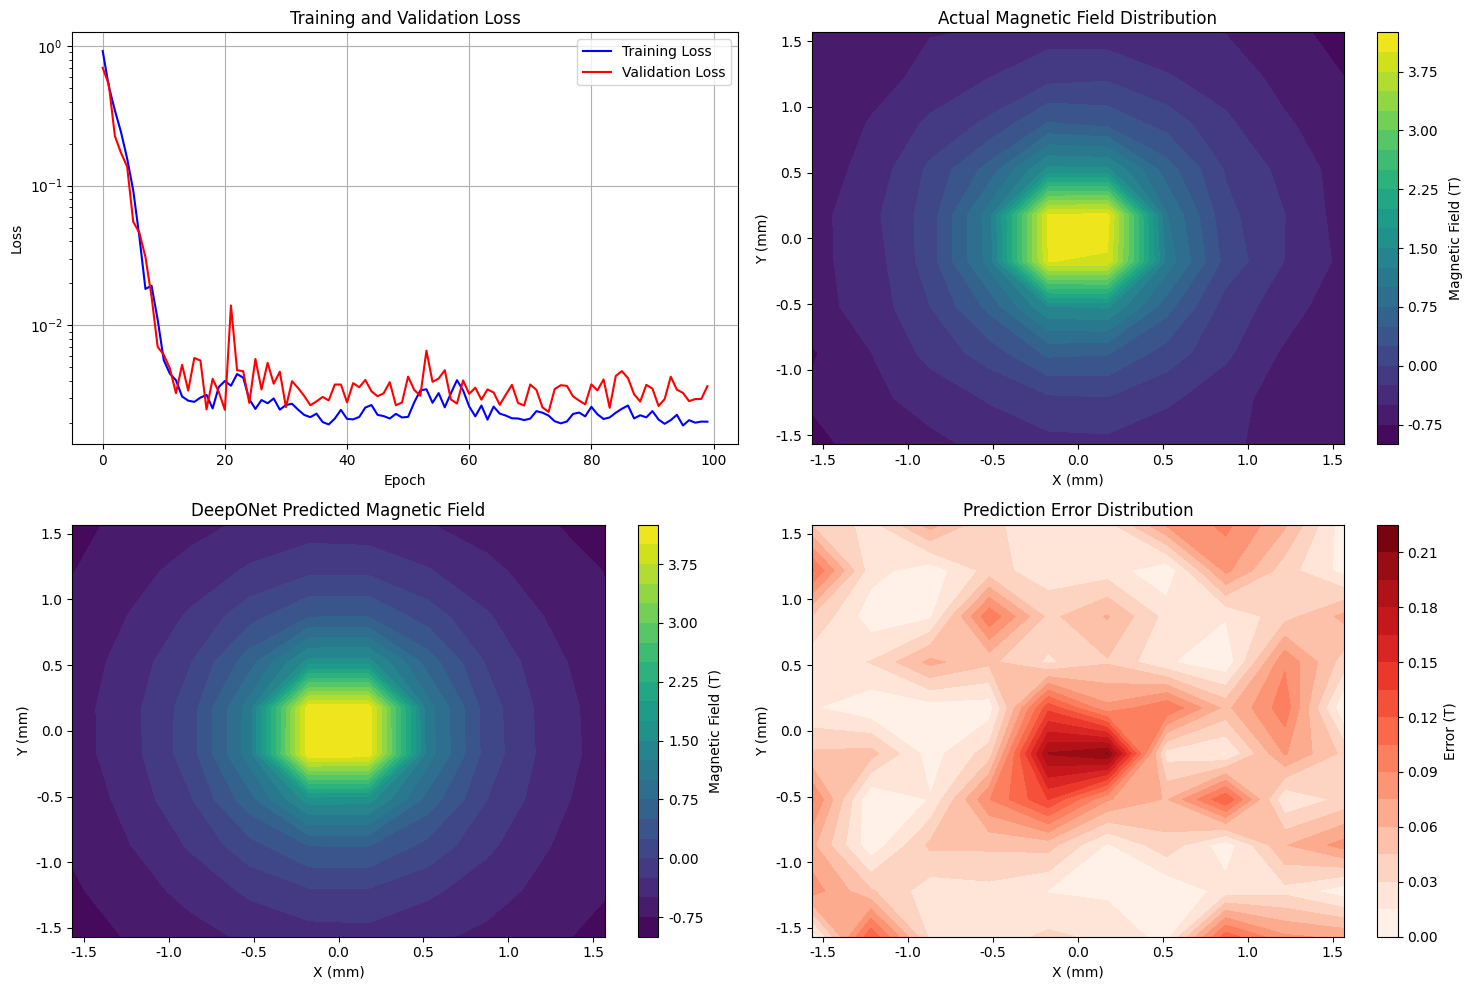

✅ DeepONet model saved successfully: deeponet_maxwell_field_model.pth
🎉 DeepONet learning workflow completed!
✅ DeepONet training successful!

🎉 DeepONet Training Completed!
🔮 DeepONet prediction demo...


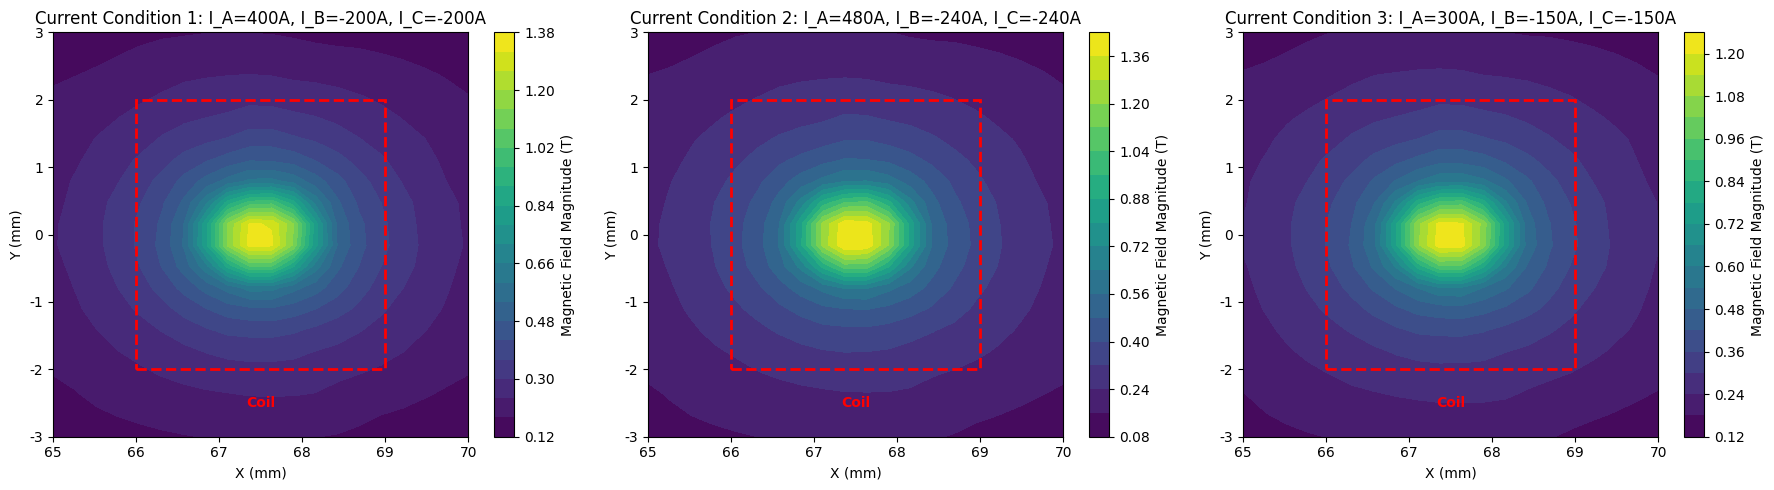

✅ DeepONet prediction demo completed!

📊 Training Results Summary:
   Final training loss: 0.002047
   Final validation loss: 0.003674
   Minimum validation loss: 0.002405 (epoch 74)

💾 Saved files:
   - deeponet_maxwell_field_model.pth (trained model)


In [37]:
# 🚀 DeepONet 학습 실행!
# Maxwell 시뮬레이션이 완료된 후 아래 코드를 실행하세요

print("=" * 60)
print("🧠 Starting DeepONet Training!")
print("=" * 60)

# Execute DeepONet training
trained_model, loss_history, scalers = execute_deeponet_training()

if trained_model is not None:
    print("\n" + "=" * 60)
    print("🎉 DeepONet Training Completed!")
    print("=" * 60)
    
    # Execute prediction demo with trained model
    demonstrate_deeponet_prediction(trained_model, scalers)
    
    print("\n📊 Training Results Summary:")
    train_losses, val_losses = loss_history
    print(f"   Final training loss: {train_losses[-1]:.6f}")
    print(f"   Final validation loss: {val_losses[-1]:.6f}")
    print(f"   Minimum validation loss: {min(val_losses):.6f} (epoch {val_losses.index(min(val_losses))+1})")
    
    print("\n💾 Saved files:")
    print("   - deeponet_maxwell_field_model.pth (trained model)")
    
else:
    print("\n❌ DeepONet training failed")
    print("Please verify that Maxwell simulation is completed and try again.")

# 📚 DeepONet 활용 가이드

## 🎯 DeepONet이란?

**DeepONet (Deep Operator Network)**는 함수-함수 매핑을 학습하는 신경망입니다. 이 예제에서는:

- **입력**: 3상 전류 파형 (시간에 따른 함수)
- **출력**: 공간상의 자기장 분포 (공간에 따른 함수)
- **목적**: 전류 조건이 주어졌을 때 코일 주변의 자기장 분포 예측

## 🔧 주요 구성 요소

### 1. Branch Network
- **역할**: 입력 함수 (전류 파형)를 특징 벡터로 변환
- **입력**: 3상 전류 값 [I_A, I_B, I_C]
- **출력**: 고차원 특징 벡터

### 2. Trunk Network  
- **역할**: 공간 좌표를 기저 함수로 변환
- **입력**: 공간 좌표 [x, y]
- **출력**: 기저 함수 벡터

### 3. 결합 레이어
- **역할**: Branch와 Trunk 출력을 내적으로 결합
- **출력**: 각 공간 위치에서의 자기장 값

## 🚀 실제 활용 방안

### 1. 모터 설계 최적화
```python
# 다양한 전류 조건에서 빠른 필드 예측
currents = [[400, -200, -200], [480, -240, -240]]
predictions = model.predict(currents, spatial_coords)
```

### 2. 실시간 제어
- Maxwell 시뮬레이션 대신 DeepONet으로 실시간 필드 예측
- 제어 시스템에서 빠른 응답을 위한 대리 모델

### 3. 파라미터 스터디
- 수천 가지 조건을 빠르게 평가
- 최적 전류 조건 탐색

## ⚡ 성능 향상 팁

1. **더 많은 데이터**: Maxwell 시뮬레이션 결과를 더 많이 수집
2. **네트워크 깊이 조정**: `num_layers` 파라미터 튜닝
3. **정규화 기법**: Dropout, Batch Normalization 추가
4. **앙상블**: 여러 모델의 예측 결과 평균

## 🔬 확장 가능성

- **다중 물리**: 열전달, 구조 해석과 결합
- **3D 모델**: 3차원 모터 해석
- **시간 의존성**: 과도 현상 예측
- **불확실성 정량화**: Bayesian DeepONet